In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# читаем данные, тут разделитель точка с запятой
df = pd.read_csv('bank-additional-full.csv', sep=';')
print("Размер данных:", df.shape)

# чекаем пропуски
print("Пропусков:", df.isnull().sum().sum())

# удаляем дубликаты, если есть
dups = df.duplicated().sum()
print("Дубликатов до очистки:", dups)

if dups > 0:
    df.drop_duplicates(inplace=True)
    print("Размер после дропа дубликатов:", df.shape)

Размер данных: (41188, 21)
Пропусков: 0
Дубликатов до очистки: 12
Размер после дропа дубликатов: (41176, 21)


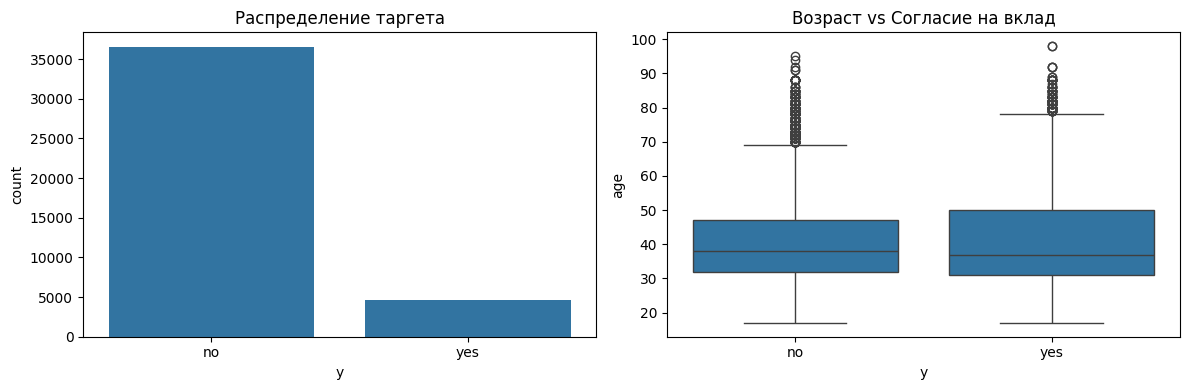

In [2]:
# глянем на баланс классов и возраст
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x='y', data=df, ax=ax[0])
ax[0].set_title('Распределение таргета')

sns.boxplot(x='y', y='age', data=df, ax=ax[1])
ax[1].set_title('Возраст vs Согласие на вклад')

plt.tight_layout()
plt.show()

In [3]:
from sklearn.model_selection import train_test_split

# переводим таргет в бинарный формат
df['y'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)

df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

# бьем на трейн и тест с сохранением баланса классов (stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (32940, 53)
Test: (8236, 53)


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, classification_report

# обучаем обычную логрегрессию как бейзлайн
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)

# предикт
preds = logreg.predict(X_test)
preds_proba = logreg.predict_proba(X_test)[:, 1]

# смотрим качество
print("ROC-AUC:", round(roc_auc_score(y_test, preds_proba), 4))
print("F1:", round(f1_score(y_test, preds), 4))
print("\nClassification report:\n", classification_report(y_test, preds))

ROC-AUC: 0.9365
F1: 0.5138

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.97      0.95      7308
           1       0.66      0.42      0.51       928

    accuracy                           0.91      8236
   macro avg       0.80      0.70      0.73      8236
weighted avg       0.90      0.91      0.90      8236



In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, f1_score, classification_report
import time
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv('bank-additional-full.csv', sep=';')
df.drop_duplicates(inplace=True)
df['y'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

experiments = []

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    start_time = time.time()
    model.fit(X_tr, y_tr)
    fit_time = time.time() - start_time

    preds = model.predict(X_te)
    preds_proba = model.predict_proba(X_te)[:, 1]

    roc_auc = roc_auc_score(y_te, preds_proba)
    f1 = f1_score(y_te, preds)

    experiments.append({
        'Model': name,
        'ROC-AUC': round(roc_auc, 4),
        'F1-Score': round(f1, 4),
        'Train Time (s)': round(fit_time, 2)
    })
    return model

#Baseline
logreg = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
evaluate_model('LogReg (Balanced)', logreg, X_train_scaled, y_train, X_test_scaled, y_test)

#KNN
knn = KNeighborsClassifier(n_neighbors=5)
evaluate_model('KNN', knn, X_train_scaled, y_train, X_test_scaled, y_test)

#Random Forest
rf = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)
evaluate_model('Random Forest', rf, X_train_scaled, y_train, X_test_scaled, y_test)

#LightGBM
lgbm = LGBMClassifier(random_state=42, class_weight='balanced', n_jobs=-1)
evaluate_model('LightGBM', lgbm, X_train_scaled, y_train, X_test_scaled, y_test)

#Тюнинг гиперпараметров LightGBM
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5, 7]
}
lgbm_grid = GridSearchCV(LGBMClassifier(random_state=42, class_weight='balanced'),
                         param_grid, cv=3, scoring='f1', n_jobs=-1)
evaluate_model('LightGBM (Tuned)', lgbm_grid, X_train_scaled, y_train, X_test_scaled, y_test)

pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Размерность после PCA: {X_train_pca.shape[1]} признаков (было {X_train_scaled.shape[1]})")

lgbm_pca = LGBMClassifier(random_state=42, class_weight='balanced', n_jobs=-1)
evaluate_model('LightGBM (PCA)', lgbm_pca, X_train_pca, y_train, X_test_pca, y_test)

results_df = pd.DataFrame(experiments).sort_values(by='F1-Score', ascending=False)
print("\nТаблица экспериментов:")
print(results_df.to_markdown(index=False))

[LightGBM] [Info] Number of positive: 3711, number of negative: 29229
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012712 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 722
[LightGBM] [Info] Number of data points in the train set: 32940, number of used features: 51
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] Number of positive: 3711, number of negative: 29229
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015933 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 722
[LightGBM] [Info] Number of data points in the train set: 32940, number of used features: 51
[LightGBM] [Info] [bin

In [6]:
import numpy as np
from sklearn.metrics import precision_recall_curve

preds_proba = lgbm_grid.predict_proba(X_test_scaled)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, preds_proba)

#F1 для каждого возможного порога
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

#лучший порог
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Оптимальный порог: {best_threshold:.4f}")
print(f"Новый максимальный F1-Score: {best_f1:.4f}")


Оптимальный порог: 0.7197
Новый максимальный F1-Score: 0.6541


In [7]:
import joblib

#лучшая модель
model_artifacts = {
    'scaler': scaler,
    'model': lgbm_grid.best_estimator_,
    'threshold': 0.7197
}


joblib.dump(model_artifacts, 'bank_deposit_model.pkl')

['bank_deposit_model.pkl']

In [8]:
!pip install fastapi uvicorn pydantic nest-asyncio

In [9]:
from fastapi import FastAPI
from pydantic import BaseModel
from typing import List
import joblib
import numpy as np
import warnings
import nest_asyncio
import uvicorn
import threading
warnings.filterwarnings('ignore')

app = FastAPI(title="Bank Deposit Predictor API")


artifacts = joblib.load('bank_deposit_model.pkl')
model = artifacts['model']
scaler = artifacts['scaler']
threshold = float(artifacts['threshold'])

class PredictRequest(BaseModel):
    features: List[float]

@app.post("/predict")
def predict(request: PredictRequest):
    try:
        x_input = np.array([request.features])
        x_scaled = scaler.transform(x_input)
        proba = model.predict_proba(x_scaled)[:, 1][0]
        prediction = 1 if proba >= threshold else 0

        return {
            "probability": float(round(proba, 4)),
            "prediction": int(prediction),
            "result": "Клиент откроет депозит." if prediction == 1 else "Отказ."
        }
    except Exception as e:

        return {"error": str(e)}

@app.get("/")
def root():
    return {"status": "API is running."}

nest_asyncio.apply()

def run_server():
    uvicorn.run(app, host="127.0.0.1", port=8000)

thread = threading.Thread(target=run_server)
thread.start()


In [11]:
import json


positive_clients = X_test[y_test == 1]
negative_clients = X_test[y_test == 0]

print("Откроют депозит")
for i in range(2):

    features = [float(x) for x in positive_clients.iloc[i]]
    print(f"{i+1} ---")
    print(json.dumps({"features": features}))
    print()

print("Не откроют депозит")
for i in range(2):

    features = [float(x) for x in negative_clients.iloc[i]]
    print(f"{i+1} ---")
    print(json.dumps({"features": features}))
    print()

Откроют депозит
1 ---
{"features": [30.0, 282.0, 2.0, 6.0, 1.0, -1.1, 94.199, -37.5, 0.88, 4963.6, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0]}

2 ---
{"features": [31.0, 1001.0, 4.0, 999.0, 0.0, 1.1, 93.994, -36.4, 4.856, 5191.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0]}

Не откроют депозит
1 ---
{"features": [35.0, 173.0, 14.0, 999.0, 0.0, 1.4, 94.465, -41.8, 4.864, 5228.1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0]}

2 ---
{"features": [37.0, 180.0, 3.0, 999.0, 1.0, -1.8, 92.

In [12]:

import urllib
print("Endpoint IP:", urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip("\n"))

!npx localtunnel --port 8000

Ваш пароль для туннеля (Endpoint IP): 34.139.245.122
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙your url is: https://dirty-hoops-count.loca.lt
INFO:     89.124.117.85:0 - "GET /docs HTTP/1.1" 200 OK
INFO:     89.124.117.85:0 - "GET /openapi.json HTTP/1.1" 200 OK
INFO:     89.124.117.85:0 - "GET /docs/docs HTTP/1.1" 404 Not Found
INFO:     89.124.117.85:0 - "GET /favicon.ico HTTP/1.1" 404 Not Found
INFO:     89.124.117.85:0 - "POST /predict HTTP/1.1" 200 OK
INFO:     213.180.203.224:0 - "GET /robots.txt HTTP/1.1" 404 Not Found
INFO:     87.250.224.88:0 - "GET / HTTP/1.1" 200 OK
INFO:     89.124.117.85:0 - "POST /predict HTTP/1.1" 200 OK
INFO:     89.124.117.85:0 - "POST /predict HTTP/1.1" 200 OK
INFO:     89.124.117.85:0 - "POST /predict HTTP/1.1" 200 OK
INFO:     89.124.117.85:0 - "POST /predict HTTP/1.1" 200 OK
^C
